In [1]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv("nt_crime_merged.csv")

mapping = {
    "01 Homicide": "homicide",
    "02 Assault": "assault",
    "03 Sexual offences": "sexual",
    "04 Harm or endanger persons": "harm_endanger",
    "05 Robbery, blackmail, and extortion": "robbery_extortion",
    "061 Burglary - dwelling": "burglary_dwelling",
    "062 Burglary - non-residential": "burglary_nonres",
    "07 Theft": "theft",
    "11 Property damage offences": "property_damage"
}

mapping_type = {
    "0110 Murder": "murder",
    "0131 Manslaughter": "manslaughter",
    "0132 Driving causing death": "driving_causing_death",

    "021 Serious Assault": "serious_assault",
    "022 Assault of a prescribed officer": "assault_officer",
    "023 Common Assault": "common_assault",

    "031 Sexual assault of an adult": "sexual_adult",
    "032 Sexual assault of a child": "sexual_child",
    "033, 034 Other child-related sexual offences": "sexual_child_other",
    "035, 039 Other sexual offences": "sexual_other",

    "041, 042, 043 Human trafficking, abduction, deprivation of liberty": "human_trafficking_abduction",
    "044 Acts that threaten, harass or control": "threaten_harass_control",
    "049 Other acts that harm or endanger persons": "harm_endanger_other",
    "045 Driving causing serious injury": "driving_serious_injury",

    "051 Robbery": "robbery",
    "052 Blackmail or other extortion": "extortion",

    "061 Burglary - dweling (house break-ins), attempted": "burglary_dwelling_attempted",
    "061 Burglary - dwelling (house break-ins), actual": "burglary_dwelling_actual",
    "062 Burglary - non-residential (commercial break-ins), actual": "burglary_nonres_actual",
    "062 Burglary - non-residential (commercial break-ins), attempted": "burglary_nonres_attempted",

    "07* Other theft": "theft_other",
    "071 Motor vehicle theft and related offences": "theft_vehicle",

    "11 Property damage offences": "property_damage"
}


df["Offence type"] = df["Offence type"].map(mapping_type)
df['Offence category'] = df['Offence category'].map(mapping)
df["Offence type"].unique()
df = pd.get_dummies(df, columns=['Offence category', 'Offence type'], prefix = 'off')
df.drop(columns = ['Region'], inplace=True)

df.columns
df_assault = df[df['off_assault'] == True]

# df_assault.to_csv("thomas_processed.csv")

# Sum DV / alcohol involvement flags
region_cols = [col for col in df.columns if col.startswith('Region_')]
df['region'] = df[region_cols].idxmax(axis=1).str.replace('Region_', '')

agg_dict = {}

for col in df.columns:
    if col in ['region', 'Year', 'Month number']:
        continue

    # SUM columns that should be aggregated
    elif col in ['Number of offences', 'Alcohol involvement', 'DV involvement']:
        agg_dict[col] = 'sum'

    # Everything else: keep first value (already aggregated stats)
    elif col.__contains__("PAC") or col.startswith("Pop") or col in ["Total_population", "Aboriginal", "Non-Aboriginal", "Male", "Female"]:
        agg_dict[col] = 'first'
    
    
df = (
    df.groupby(['region', 'Year', 'Month number'])
      .agg(agg_dict)
      .reset_index()
)
df
df["assault_rate"] = df["Number of offences"] / df["Total_population"] * 1000
df.columns 
# df_region_month.to_csv("thomas_processed.csv")

#Cyclic month encoding
df['sin_month'] = np.sin(2 * np.pi * df['Month number'] / 12)
df['cos_month'] = np.cos(2 * np.pi * df['Month number'] / 12)

#Demographic proportion
df['pct_aboriginal'] = df['Aboriginal'] / df['Total_population']
df['pct_male'] = df['Male'] / df['Total_population']
df['pct_youth'] = (df['Pop_age_15'] + df['Pop_age_20']) / df['Total_population']
df['pct_senior'] = (
    df['Pop_age_65'] + df['Pop_age_70'] + df['Pop_age_75'] +
    df['Pop_age_80'] + df['Pop_age_85plus']
) / df['Total_population']

#Normalise PAC values
df['alcohol_per_capita'] = df['Total PAC'] / df['Total_population']
df['beer_per_capita'] = (
    df['Full-Strength Beer PAC'] +
    df['Mid-Strength Beer PAC'] +
    df['Low-Strength Beer PAC']
) / df['Total_population']
df['wine_per_capita'] = (
    df['Cask Wine PAC'] +
    df['Bottled Wine PAC'] +
    df['Fortified Wine PAC']
) / df['Total_population']

#adding lag
df['assault_rate_lag1'] = df.groupby('region')['assault_rate'].shift(1)
df['assault_rate_lag3'] = df.groupby('region')['assault_rate'].shift(3)

df.to_csv("thomas_processed.csv")



Research question 2 - Predicts monthly assult rates for each NT region using past crime data, population characteristics and alcohol supply volume


RMSE: 26.93033431519785
MAE: 9.492189978707973
MAPE: 19.529461995759547


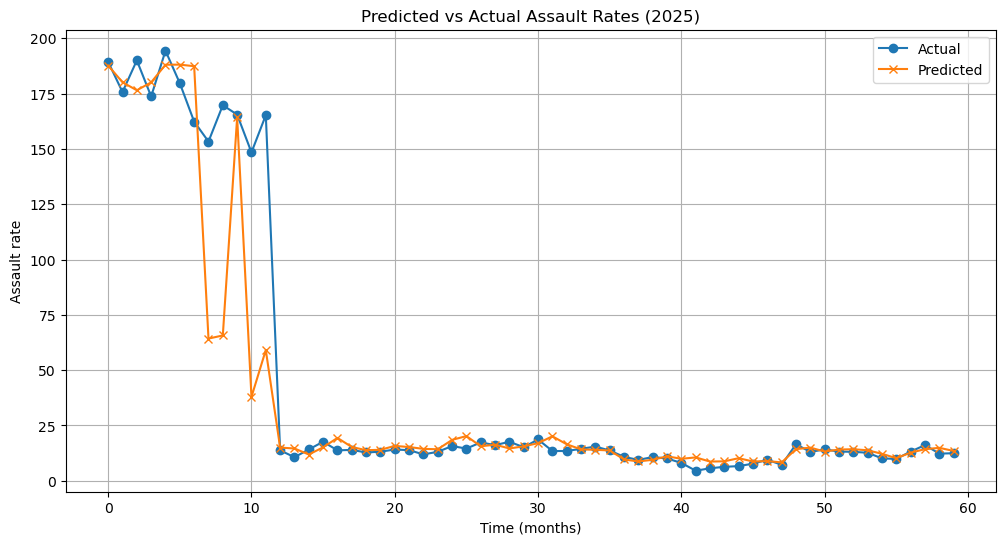

In [3]:


# Ensure proper ordering
df = df.sort_values(['region', 'Year', 'Month number'])


# Drop rows where lag features are missing
df = df.dropna(subset=['assault_rate_lag1', 'assault_rate_lag3'])

# --- Train/test split ---
train = df[df['Year'] == 2024]
test  = df[df['Year'] == 2025]


feature_cols = [
    # Time features
    'sin_month',

    # Lag features
    'assault_rate_lag1', 'assault_rate_lag3',

    # Demographics
    'Total_population', 'pct_aboriginal', 'pct_male',
    'pct_youth', 'pct_senior',

    # Alcohol supply
    'Total PAC', 'alcohol_per_capita', 'beer_per_capita', 'wine_per_capita',

    # Crime context
    'Alcohol involvement', 'DV involvement'
]

# Train = 2024, Test = 2025
train = df[df['Year'] == 2024]
test  = df[df['Year'] == 2025]

X_train = train[feature_cols]
y_train = train['assault_rate']

X_test = test[feature_cols]
y_test = test['assault_rate']


model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.9,
    colsample_bytree=0.9,
    objective='reg:squarederror',
    random_state=42
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, pred))
mae = mean_absolute_error(y_test, pred)
mape = np.mean(np.abs((y_test - pred) / y_test)) * 100

print("RMSE:", rmse)
print("MAE:", mae)
print("MAPE:", mape)

plt.figure(figsize=(12,6))
plt.plot(test['assault_rate'].values, label='Actual', marker='o')
plt.plot(pred, label='Predicted', marker='x')
plt.title('Predicted vs Actual Assault Rates (2025)')
plt.xlabel('Time (months)')
plt.ylabel('Assault rate')
plt.legend()
plt.grid(True)
plt.show()


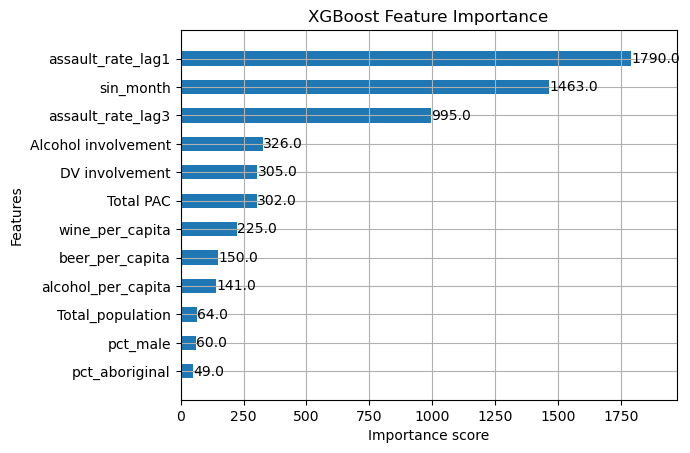

In [4]:

xgb.plot_importance(model, max_num_features=20, height=0.5)
plt.title("XGBoost Feature Importance")
plt.show()

In [5]:
df.columns

Index(['region', 'Year', 'Month number', 'Alcohol involvement',
       'DV involvement', 'Total_population', 'Aboriginal', 'Non-Aboriginal',
       'Male', 'Female', 'Pop_age_0', 'Pop_age_10', 'Pop_age_15', 'Pop_age_20',
       'Pop_age_25', 'Pop_age_30', 'Pop_age_35', 'Pop_age_40', 'Pop_age_45',
       'Pop_age_5', 'Pop_age_50', 'Pop_age_55', 'Pop_age_60', 'Pop_age_65',
       'Pop_age_70', 'Pop_age_75', 'Pop_age_80', 'Pop_age_85plus',
       'Cask Wine PAC', 'Bottled Wine PAC', 'Fortified Wine PAC', 'Cider PAC',
       'Standard Spirits PAC', 'Mixed Spirits PAC', 'Full-Strength Beer PAC',
       'Mid-Strength Beer PAC', 'Low-Strength Beer PAC', 'Total PAC',
       'Number of offences', 'assault_rate', 'sin_month', 'cos_month',
       'pct_aboriginal', 'pct_male', 'pct_youth', 'pct_senior',
       'alcohol_per_capita', 'beer_per_capita', 'wine_per_capita',
       'assault_rate_lag1', 'assault_rate_lag3'],
      dtype='object')

In [ ]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import root_mean_squared_error
import numpy as np



features = [
    "sin_month",
    "cos_month",
    "assault_rate_lag1",
    "assault_rate_lag3",
    "Total_population",
    "Alcohol involvement",
    "DV involvement",
    "Total PAC",
    "alcohol_per_capita",
    "beer_per_capita",
    "wine_per_capita",
    "pct_aboriginal",
    "pct_male",
    "pct_youth",
    "pct_senior",

]

# --- 1. Drop rows with NaN in any baseline feature ---
df_clean = df.dropna(subset=[
    "assault_rate_lag1",
    "assault_rate_lag3",
    "assault_rate"
]).copy()

train = df_clean[df_clean["Year"] == 2024]
test  = df_clean[df_clean["Year"] == 2025]



train = df_clean[df_clean["Year"] == 2024]
test  = df_clean[df_clean["Year"] == 2025]
print(train.shape, test.shape)

X_train = train[features]
y_train = train["assault_rate"]

X_test = test[features]
y_test = test["assault_rate"]

model = LinearRegression()
model.fit(X_train, y_train)

preds = model.predict(X_test)
rmse = root_mean_squared_error(y_test, preds)

print("Test RMSE:", rmse)


(45, 51) (60, 51)
Test RMSE: 11.27939375103543


: 